In [4]:
import zipfile
with zipfile.ZipFile('/ml-32m.zip', "r") as z:
    z.extractall(".")

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("Files in current directory:", os.listdir())

Files in current directory: ['.config', 'ml-32m', 'sample_data']


In [8]:
# Adjust paths if your files are inside a folder
ratings = pd.read_csv("ml-32m/ratings.csv")
movies = pd.read_csv("ml-32m/movies.csv")

print("Loaded successfully.")

Loaded successfully.


In [9]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Ratings shape: {ratings.shape}")
print(f"Movies shape:  {movies.shape}")

print("\nRatings columns:", ratings.columns.tolist())
print("Movies columns: ", movies.columns.tolist())

DATASET OVERVIEW
Ratings shape: (32000204, 4)
Movies shape:  (87585, 3)

Ratings columns: ['userId', 'movieId', 'rating', 'timestamp']
Movies columns:  ['movieId', 'title', 'genres']


In [10]:
print("Missing values (ratings):")
print(ratings.isnull().sum())
print("\nMissing values (movies):")
print(movies.isnull().sum())

Missing values (ratings):
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Missing values (movies):
movieId    0
title      0
genres     0
dtype: int64


In [11]:
print("Sample ratings:")
print(ratings.head())

print("\nSample movies:")
print(movies.head())

Sample ratings:
   userId  movieId  rating  timestamp
0       1       17     4.0  944249077
1       1       25     1.0  944250228
2       1       29     2.0  943230976
3       1       30     5.0  944249077
4       1       32     5.0  943228858

Sample movies:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


In [12]:
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
n_interactions = len(ratings)
sparsity = 1 - (n_interactions / (n_users * n_movies))

print("=" * 50)
print("STATISTICS")
print("=" * 50)
print(f"Unique users:       {n_users}")
print(f"Unique movies:      {n_movies}")
print(f"Total interactions: {n_interactions}")
print(f"Sparsity:           {sparsity:.4f} ({sparsity*100:.2f}%)")

STATISTICS
Unique users:       200948
Unique movies:      84432
Total interactions: 32000204
Sparsity:           0.9981 (99.81%)


In [13]:
print("Rating distribution:")
print(ratings['rating'].value_counts().sort_index())

Rating distribution:
rating
0.5     525132
1.0     946675
1.5     531063
2.0    2028622
2.5    1685386
3.0    6054990
3.5    4290105
4.0    8367654
4.5    2974000
5.0    4596577
Name: count, dtype: int64


In [14]:
ratings_per_user = ratings.groupby('userId').size()
ratings_per_movie = ratings.groupby('movieId').size()

print(f"Ratings per user — min: {ratings_per_user.min()}, "
      f"max: {ratings_per_user.max()}, "
      f"mean: {ratings_per_user.mean():.1f}")

print(f"Ratings per movie — min: {ratings_per_movie.min()}, "
      f"max: {ratings_per_movie.max()}, "
      f"mean: {ratings_per_movie.mean():.1f}")

Ratings per user — min: 20, max: 33332, mean: 159.2
Ratings per movie — min: 1, max: 102929, mean: 379.0


In [15]:
all_genres = movies['genres'].str.split('|').explode()
print(f"Unique genres: {all_genres.nunique()}")
print("\nGenre distribution:")
print(all_genres.value_counts())

Unique genres: 20

Genre distribution:
genres
Drama                 34175
Comedy                23124
Thriller              11823
Romance               10369
Action                 9668
Documentary            9363
Horror                 8654
(no genres listed)     7080
Crime                  6976
Adventure              5402
Sci-Fi                 4907
Animation              4617
Children               4520
Mystery                4013
Fantasy                3851
War                    2325
Western                1696
Musical                1059
Film-Noir               353
IMAX                    195
Name: count, dtype: int64


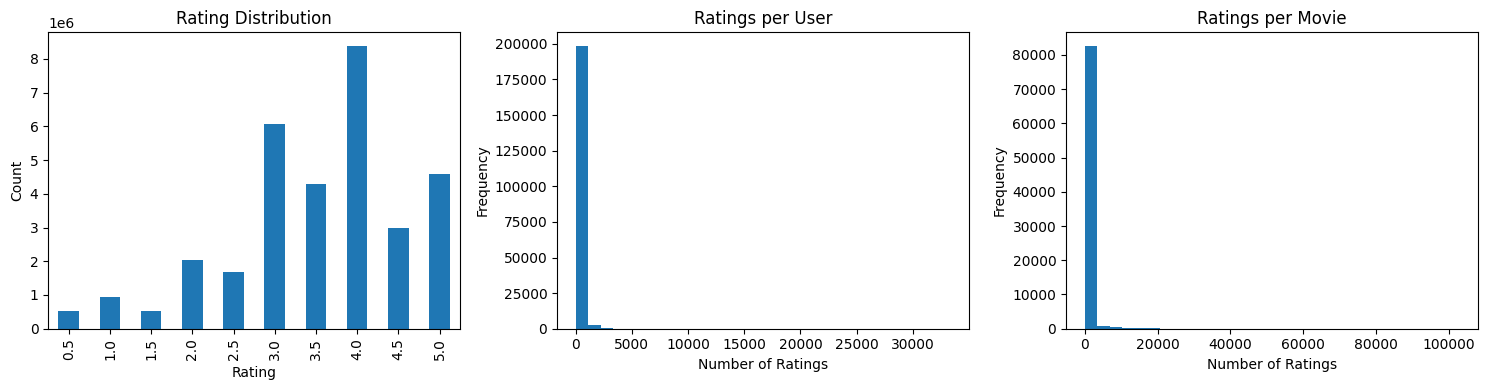

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], title='Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

ratings_per_user.plot(
    kind='hist', bins=30, ax=axes[1], title='Ratings per User')
axes[1].set_xlabel('Number of Ratings')

ratings_per_movie.plot(
    kind='hist', bins=30, ax=axes[2], title='Ratings per Movie')
axes[2].set_xlabel('Number of Ratings')

plt.tight_layout()
plt.savefig('data_overview.png', dpi=100)
plt.show()

In [17]:
# Save summary to a text file you can download
with open("data_summary.txt", "w") as f:
    f.write(f"Unique users: {n_users}\n")
    f.write(f"Unique movies: {n_movies}\n")
    f.write(f"Total interactions: {n_interactions}\n")
    f.write(f"Sparsity: {sparsity:.4f} ({sparsity*100:.2f}%)\n")

from google.colab import files
files.download("data_summary.txt")
files.download("data_overview.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>